In [8]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler
import h5py

In [33]:
import logging

logging.basicConfig(
    format='[%(asctime)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    level=logging.DEBUG
)

logger = logging.getLogger()
logger.info("hi")  # Same clean output

[2025-12-09 19:16:23] hi


In [34]:
# Constants
METADATA_PATH = "/home/wyf/orcd/pool/diffrhythm/metadata.json"
ACTS_BY_LAYER_PATH = Path("/home/wyf/orcd/pool/diffrhythm/acts_by_layer")

In [36]:
with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

LAYER_IDX = 12
layer_acts = np.load(ACTS_BY_LAYER_PATH / f"layer_{LAYER_IDX:02d}.npy")
print(f"{layer_acts.shape=}")

layer_acts.shape=(399, 256, 2048)


In [59]:
# Define main fitting function based on layer idx
class_labels = ["major", "minor"]

def train_linear_probe(
    layer_idx: int,
    pca_dim: int,
    pooling_strat: str,
    test_size=0.3,
    n_tests: int = 1024,
):
    acts = np.load(ACTS_BY_LAYER_PATH / f"layer_{layer_idx:02d}.npy")
    logger.info(f"Logistic regression on {layer_idx=}")

    # Pool across time
    logger.info("Pooling...")
    if pooling_strat == "max":
        X_pooled = np.max(acts, axis=1)
    else:
        X_pooled = np.mean(acts, axis=1)

    # Normalize per feature
    logger.info("Normalizing...")
    X_norm = StandardScaler().fit_transform(X_pooled)

    # Run PCA to reduce dimensionality
    from sklearn.decomposition import PCA

    logger.info("Running pca...")
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X_norm)     # shape: (1000, pca_dim)
    y_raw = np.array([
        class_labels.index(clip["key_info"]["mode"])
        for clip in metadata[:len(acts)]
    ])

    # Make train/test splits
    logger.info("Making test splits...")

    for _ in range(n_tests):
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X_pca, y_raw,
            test_size=test_size,
            stratify=y_raw,
        )

        # Run logistic regression
        from sklearn.linear_model import LogisticRegression

        # logger.info("Fitting logistic regression...")
        reg = LogisticRegression()
        reg.fit(X_train, y_train)

        # Plot confusion matrix
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

        def evaluate(X, y):
            y_pred = reg.predict(X) >= 0.5

            cm = confusion_matrix(y, y_pred)
            # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
            # disp.plot()
            
            acc = accuracy_score(y, y_pred)
            return cm, acc
        
        # logger.info("Running eval...")
        _, train_acc = evaluate(X_train, y_train)
        _, test_acc = evaluate(X_test, y_test)

        print(f"[{layer_idx=}]  train_acc={train_acc * 100:.3f}%, test_acc={test_acc * 100:.3f}")
        yield train_acc, test_acc

In [60]:
records = []

In [61]:
# logger.setLevel("ERROR")
logger.setLevel("DEBUG")

# Runs in 2m
for layer_idx in [0, 4, 8, 12]:
    accs = list(train_linear_probe(
        layer_idx,
        pca_dim=2,
        pooling_strat="max",
        test_size=0.3,
        n_tests=1024,
    ))
    records.append((layer_idx, accs))

[2025-12-09 19:20:01] Logistic regression on layer_idx=0
[2025-12-09 19:20:01] Pooling...
[2025-12-09 19:20:01] Normalizing...
[2025-12-09 19:20:01] Running pca...
[2025-12-09 19:20:01] Making test splits...


[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=61.290%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=61.290%, test_acc=60.833
[layer_idx=0]  train_acc=60.573%, test_acc=61.667
[layer_idx=0]  train_acc=60.932%, test_acc=61.667
[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=61.667
[layer_idx=0]  train_acc=61.290%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=61.667
[layer_idx=0]  train_acc=60.573%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=61.667
[layer_idx=0]  train_acc=60.932%, test_acc=60.833
[layer_idx=0]  train_acc=60.573%, test_acc=60.833
[layer_idx=0]  train_acc=61.290%, test_acc=60.833
[layer_idx=0]  train_acc=60.932%, test_acc=61.667
[layer_idx=0]  train_acc=61.290%, test_acc=60.833


[2025-12-09 19:20:06] Logistic regression on layer_idx=4
[2025-12-09 19:20:06] Pooling...
[2025-12-09 19:20:06] Normalizing...
[2025-12-09 19:20:06] Running pca...
[2025-12-09 19:20:06] Making test splits...


[layer_idx=4]  train_acc=60.932%, test_acc=60.833
[layer_idx=4]  train_acc=61.290%, test_acc=60.833
[layer_idx=4]  train_acc=60.573%, test_acc=61.667
[layer_idx=4]  train_acc=60.932%, test_acc=61.667
[layer_idx=4]  train_acc=61.290%, test_acc=60.833
[layer_idx=4]  train_acc=61.290%, test_acc=60.000
[layer_idx=4]  train_acc=60.573%, test_acc=60.833
[layer_idx=4]  train_acc=60.932%, test_acc=61.667
[layer_idx=4]  train_acc=61.290%, test_acc=60.833
[layer_idx=4]  train_acc=60.573%, test_acc=60.833
[layer_idx=4]  train_acc=60.932%, test_acc=60.833
[layer_idx=4]  train_acc=61.290%, test_acc=60.833
[layer_idx=4]  train_acc=61.290%, test_acc=60.000
[layer_idx=4]  train_acc=60.932%, test_acc=60.833
[layer_idx=4]  train_acc=60.932%, test_acc=60.833
[layer_idx=4]  train_acc=60.932%, test_acc=61.667
[layer_idx=4]  train_acc=60.932%, test_acc=61.667
[layer_idx=4]  train_acc=61.290%, test_acc=60.833
[layer_idx=4]  train_acc=60.573%, test_acc=60.833
[layer_idx=4]  train_acc=61.290%, test_acc=60.833


[2025-12-09 19:20:11] Logistic regression on layer_idx=8
[2025-12-09 19:20:11] Pooling...
[2025-12-09 19:20:11] Normalizing...
[2025-12-09 19:20:11] Running pca...
[2025-12-09 19:20:11] Making test splits...


[layer_idx=8]  train_acc=60.573%, test_acc=61.667
[layer_idx=8]  train_acc=61.290%, test_acc=60.833
[layer_idx=8]  train_acc=61.290%, test_acc=60.000
[layer_idx=8]  train_acc=60.932%, test_acc=60.833
[layer_idx=8]  train_acc=60.932%, test_acc=61.667
[layer_idx=8]  train_acc=60.573%, test_acc=60.833
[layer_idx=8]  train_acc=61.290%, test_acc=60.833
[layer_idx=8]  train_acc=60.932%, test_acc=61.667
[layer_idx=8]  train_acc=60.573%, test_acc=60.833
[layer_idx=8]  train_acc=61.290%, test_acc=60.833
[layer_idx=8]  train_acc=60.932%, test_acc=61.667
[layer_idx=8]  train_acc=61.290%, test_acc=60.000
[layer_idx=8]  train_acc=61.290%, test_acc=60.833
[layer_idx=8]  train_acc=60.932%, test_acc=60.833
[layer_idx=8]  train_acc=60.573%, test_acc=60.833
[layer_idx=8]  train_acc=60.932%, test_acc=60.833
[layer_idx=8]  train_acc=60.573%, test_acc=60.833
[layer_idx=8]  train_acc=61.290%, test_acc=60.833
[layer_idx=8]  train_acc=61.290%, test_acc=60.833
[layer_idx=8]  train_acc=61.290%, test_acc=60.833


[2025-12-09 19:20:16] Logistic regression on layer_idx=12
[2025-12-09 19:20:16] Pooling...
[2025-12-09 19:20:16] Normalizing...
[2025-12-09 19:20:16] Running pca...
[2025-12-09 19:20:16] Making test splits...


[layer_idx=12]  train_acc=63.082%, test_acc=57.500
[layer_idx=12]  train_acc=59.857%, test_acc=60.833
[layer_idx=12]  train_acc=60.932%, test_acc=60.833
[layer_idx=12]  train_acc=60.573%, test_acc=62.500
[layer_idx=12]  train_acc=61.290%, test_acc=58.333
[layer_idx=12]  train_acc=59.857%, test_acc=63.333
[layer_idx=12]  train_acc=61.649%, test_acc=65.000
[layer_idx=12]  train_acc=60.215%, test_acc=57.500
[layer_idx=12]  train_acc=60.573%, test_acc=63.333
[layer_idx=12]  train_acc=60.215%, test_acc=60.833
[layer_idx=12]  train_acc=61.290%, test_acc=59.167
[layer_idx=12]  train_acc=63.082%, test_acc=63.333
[layer_idx=12]  train_acc=61.290%, test_acc=60.000
[layer_idx=12]  train_acc=60.573%, test_acc=60.000
[layer_idx=12]  train_acc=60.932%, test_acc=58.333
[layer_idx=12]  train_acc=59.140%, test_acc=61.667
[layer_idx=12]  train_acc=60.573%, test_acc=61.667
[layer_idx=12]  train_acc=61.290%, test_acc=60.833
[layer_idx=12]  train_acc=61.649%, test_acc=61.667
[layer_idx=12]  train_acc=59.85

In [62]:
train_acc = []
test_acc = []

for idx, samples in records:
    for train, test in samples:
        train_acc.append((idx, train))
        test_acc.append((idx, test))

print(records)

[(0, [(0.6093189964157706, 0.6083333333333333), (0.6129032258064516, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6129032258064516, 0.6083333333333333), (0.6057347670250897, 0.6166666666666667), (0.6093189964157706, 0.6166666666666667), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.6166666666666667), (0.6129032258064516, 0.6083333333333333), (0.6093189964157706, 0.6166666666666667), (0.6057347670250897, 0.6083333333333333), (0.6093189964157706, 0.6166666666666667), (0.6093189964157706, 0.6083333333333333), (0.6057347670250897, 0.6083333333333333), (0.6129032258064516, 0.6083333333333333), (0.6093189964157706, 0.6166666666666667), (0.6129032258064516, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.6083333333333333), (0.6093189964157706, 0.60833

layer 00 | train: 61.06%, train: 60.88%
layer 04 | train: 61.08%, train: 60.84%
layer 08 | train: 61.07%, train: 60.84%
layer 12 | train: 61.41%, train: 60.58%


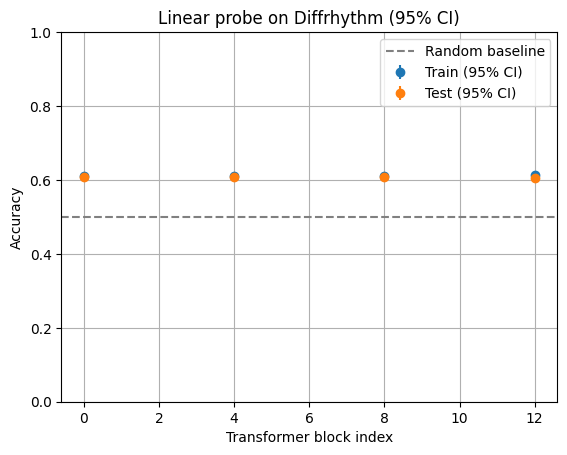

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

# Organize data by transformer block index
train_data = defaultdict(list)
test_data = defaultdict(list)

for idx, samples in records:
    for train, test in samples:
        train_data[idx].append(train)
        test_data[idx].append(test)

# Compute mean and 95% CI for each block
train_means = []
train_cis = []
test_means = []
test_cis = []
indices = sorted(train_data.keys())

for idx in indices:
    train_vals = np.array(train_data[idx])
    test_vals = np.array(test_data[idx])
    
    n_train = len(train_vals)
    n_test = len(test_vals)
    
    # Mean
    train_mean = np.mean(train_vals)
    test_mean = np.mean(test_vals)
    
    # 95% CI using t-distribution
    train_ci = stats.t.ppf(0.975, n_train-1) * np.std(train_vals, ddof=1) / np.sqrt(n_train)
    test_ci = stats.t.ppf(0.975, n_test-1) * np.std(test_vals, ddof=1) / np.sqrt(n_test)
    
    train_means.append(train_mean)
    train_cis.append(train_ci)
    test_means.append(test_mean)
    test_cis.append(test_ci)

    print(f"layer {idx:02d} | train: {train_mean*100:.2f}%, train: {test_mean*100:.2f}%")

logger.setLevel("INFO")

# Plot with 95% CI error bars
plt.errorbar(indices, train_means, yerr=train_cis, fmt='o', label="Train (95% CI)")
plt.errorbar(indices, test_means, yerr=test_cis, fmt='o', label="Test (95% CI)")
plt.xlabel("Transformer block index")
plt.ylabel("Accuracy")
plt.title("Linear probe on Diffrhythm (95% CI)")
plt.ylim((0, 1))
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=1.0, label="Random baseline")
plt.legend()

plt.grid()
plt.show()